# Praktikum Pengolahan Citra dan Visi Komputer (PCVK) - Minggu 1
## Manipulasi Citra Digital, Slicing Piksel, Bentuk Geometris, dan Anotasi Teks


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### 1. Membaca dan Memeriksa Citra Dataset `KTM2D.jpg`

Ukuran citra (Tinggi, Lebar, Kanal): (1468, 946, 3)
Tipe data: uint8


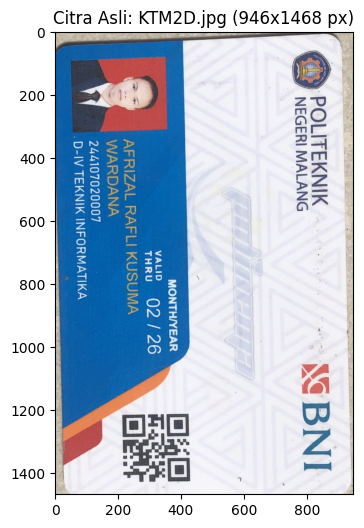

In [3]:
path_img = 'WEEK 1/KTM2D.jpg' if os.path.exists('WEEK 1/KTM2D.jpg') else 'KTM2D.jpg'
img = Image.open(path_img)
img_np = np.array(img)

print(f'Ukuran citra (Tinggi, Lebar, Kanal): {img_np.shape}')
print(f'Tipe data: {img_np.dtype}')

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title(f'Citra Asli: {os.path.basename(path_img)} ({img_np.shape[1]}x{img_np.shape[0]} px)')
plt.axis('on')
plt.show()

---
### Soal 2: Tampilkan image dalam channel Red-Blue dan Green-Blue saja!


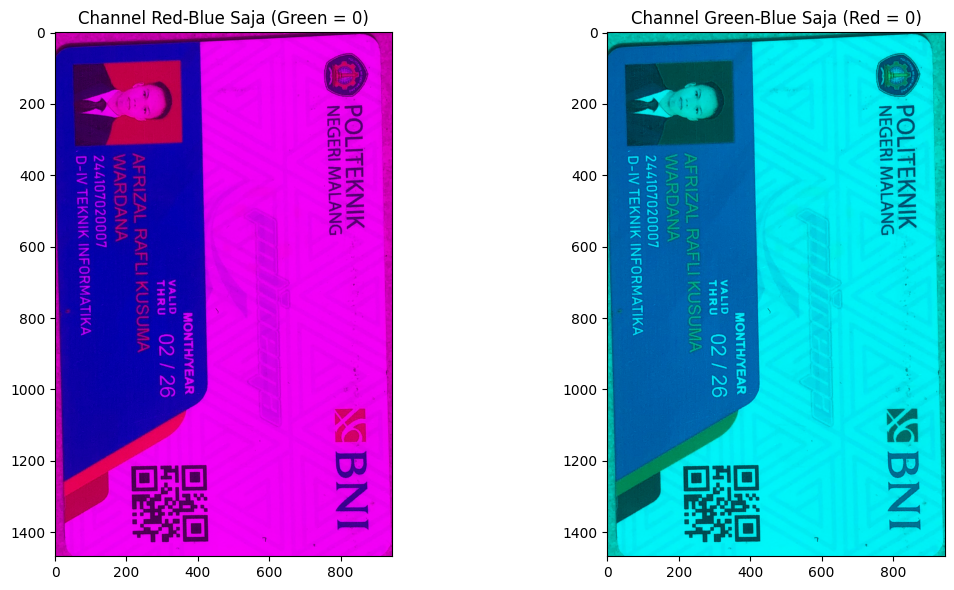

In [4]:
img_rb = img_np.copy()
img_rb[:, :, 1] = 0

img_gb = img_np.copy()
img_gb[:, :, 0] = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rb)
axes[0].set_title('Channel Red-Blue Saja (Green = 0)')
axes[0].axis('on')

axes[1].imshow(img_gb)
axes[1].set_title('Channel Green-Blue Saja (Red = 0)')
axes[1].axis('on')

plt.tight_layout()
plt.show()

---
### Soal 3: Tampilkan image baris ke 20-115, kolom 25-120!


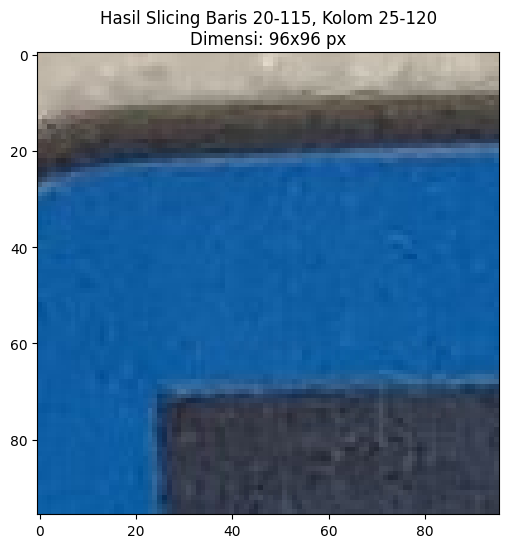

In [5]:
crop_soal3 = img_np[20:116, 25:121]

plt.figure(figsize=(6, 6))
plt.imshow(crop_soal3)
plt.title(f'Hasil Slicing Baris 20-115, Kolom 25-120\nDimensi: {crop_soal3.shape[0]}x{crop_soal3.shape[1]} px')
plt.axis('on')
plt.show()

---
### Soal 4: Tampilkan image baris ke 5-30, semua kolom, channel Red saja!


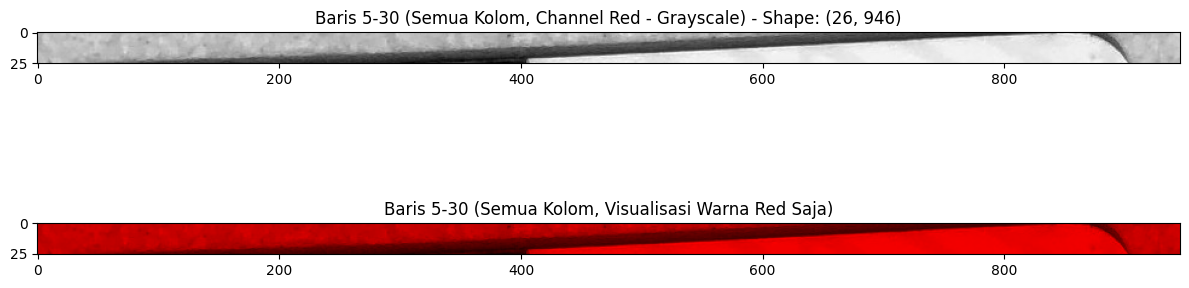

In [6]:
crop_red = img_np[5:31, :, 0]

crop_red_rgb = np.zeros((crop_red.shape[0], crop_red.shape[1], 3), dtype=np.uint8)
crop_red_rgb[:, :, 0] = crop_red

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].imshow(crop_red, cmap='gray')
axes[0].set_title(f'Baris 5-30 (Semua Kolom, Channel Red - Grayscale) - Shape: {crop_red.shape}')
axes[0].axis('on')

axes[1].imshow(crop_red_rgb)
axes[1].set_title('Baris 5-30 (Semua Kolom, Visualisasi Warna Red Saja)')
axes[1].axis('on')

plt.tight_layout()
plt.show()

---
### Soal 5: Buat 5 kotak berbagai ukuran dan warna yang berbeda dalam satu image (Random)!


Kotak 1: Posisi=(270, 1130), Ukuran=182x172 px, Warna RGB=[ 71 188  20]
Kotak 2: Posisi=(466, 1238), Ukuran=182x201 px, Warna RGB=[ 74 202  87]
Kotak 3: Posisi=(663, 130), Ukuran=196x179 px, Warna RGB=[149  52   1]
Kotak 4: Posisi=(385, 1215), Ukuran=167x117 px, Warna RGB=[187  20 160]
Kotak 5: Posisi=(252, 747), Ukuran=137x101 px, Warna RGB=[ 88  48 218]


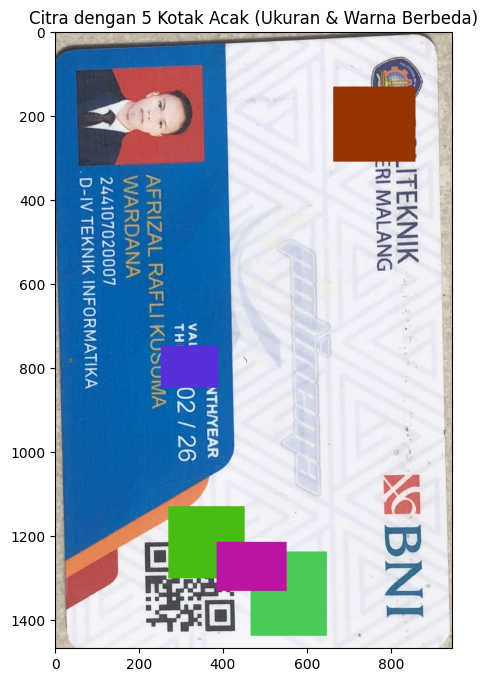

In [7]:
img_boxes = img_np.copy()
h, w, _ = img_boxes.shape

np.random.seed(42)

for i in range(5):
    box_w = np.random.randint(80, 220)
    box_h = np.random.randint(80, 220)
    
    x = np.random.randint(0, w - box_w)
    y = np.random.randint(0, h - box_h)
    
    color = np.random.randint(0, 256, 3)
    
    img_boxes[y:y+box_h, x:x+box_w] = color
    print(f'Kotak {i+1}: Posisi=({x}, {y}), Ukuran={box_w}x{box_h} px, Warna RGB={color}')

plt.figure(figsize=(8, 8))
plt.imshow(img_boxes)
plt.title('Citra dengan 5 Kotak Acak (Ukuran & Warna Berbeda)')
plt.axis('on')
plt.show()

---
### Soal 6: Tampilkan image dengan posisi terbalik!


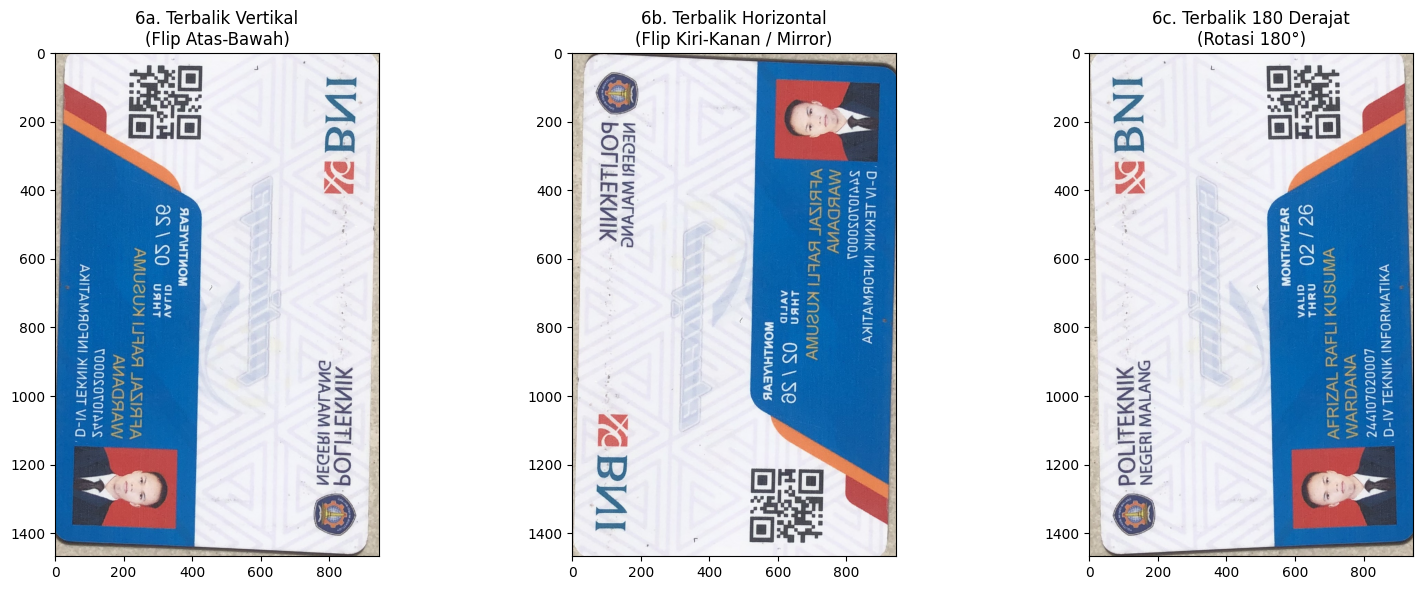

In [12]:
img_flip_v = np.flipud(img_np)
img_flip_h = np.fliplr(img_np)
img_rot_180 = np.rot90(img_np, 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(img_flip_v)
axes[0].set_title('6a. Terbalik Vertikal\n(Flip Atas-Bawah)')
axes[0].axis('on')

axes[1].imshow(img_flip_h)
axes[1].set_title('6b. Terbalik Horizontal\n(Flip Kiri-Kanan / Mirror)')
axes[1].axis('on')

axes[2].imshow(img_rot_180)
axes[2].set_title('6c. Terbalik 180 Derajat\n(Rotasi 180°)')
axes[2].axis('on')

plt.tight_layout()
plt.show()

---
### Soal 7: Buat rectangle dan circle pada bagian wajah dari image foto saat beraktivitas!



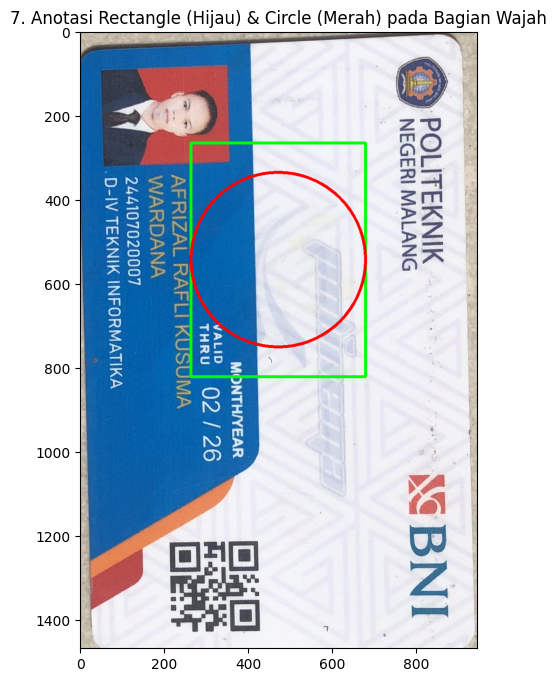

In [9]:
path_aktivitas = 'WEEK 1/foto_aktivitas.jpg' if os.path.exists('WEEK 1/foto_aktivitas.jpg') else path_img
img_act = Image.open(path_aktivitas)
img_act_rgb = np.array(img_act).copy()

h_act, w_act, _ = img_act_rgb.shape
x_wajah = int(w_act * 0.28)
y_wajah = int(h_act * 0.18)
lebar_wajah = int(w_act * 0.44)
tinggi_wajah = int(h_act * 0.38)

cv2.rectangle(img_act_rgb, (x_wajah, y_wajah), (x_wajah + lebar_wajah, y_wajah + tinggi_wajah), (0, 255, 0), 6)

pusat_x = x_wajah + lebar_wajah // 2
pusat_y = y_wajah + tinggi_wajah // 2
radius = min(lebar_wajah, tinggi_wajah) // 2

cv2.circle(img_act_rgb, (pusat_x, pusat_y), radius, (255, 0, 0), 6)

plt.figure(figsize=(8, 8))
plt.imshow(img_act_rgb)
plt.title('7. Anotasi Rectangle (Hijau) & Circle (Merah) pada Bagian Wajah')
plt.axis('on')
plt.show()

---
### Soal 8: Buat rectangle pada bagian sudut bawah kiri channel B pada color space RGB dari citra standar (lena/peppers)!


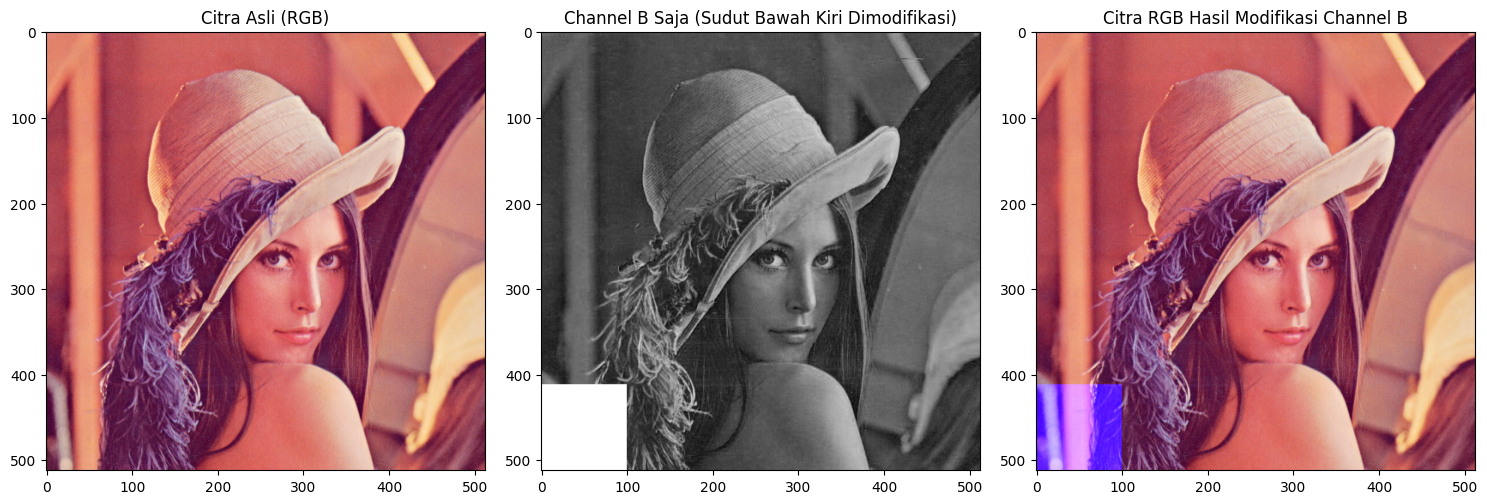

In [10]:
path_lena = 'WEEK 1/lena.jpg' if os.path.exists('WEEK 1/lena.jpg') else 'lena.jpg'
img_lena_bgr = cv2.imread(path_lena)
img_lena_rgb = cv2.cvtColor(img_lena_bgr, cv2.COLOR_BGR2RGB)

h_l, w_l, _ = img_lena_rgb.shape
box_size = 100

img_soal8 = img_lena_rgb.copy()
img_soal8[h_l - box_size : h_l, 0 : box_size, 2] = 255

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_lena_rgb)
axes[0].set_title('Citra Asli (RGB)')
axes[0].axis('on')

axes[1].imshow(img_soal8[:, :, 2], cmap='gray')
axes[1].set_title('Channel B Saja (Sudut Bawah Kiri Dimodifikasi)')
axes[1].axis('on')

axes[2].imshow(img_soal8)
axes[2].set_title('Citra RGB Hasil Modifikasi Channel B')
axes[2].axis('on')

plt.tight_layout()
plt.show()

---
### Soal 9: Lengkapi tulisan nama file pada file citra dari soal no. 8!


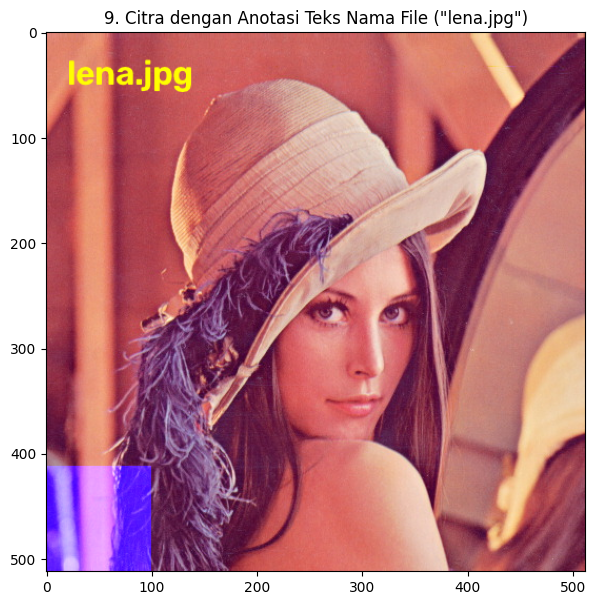

In [11]:
img_soal9 = img_soal8.copy()
nama_file = os.path.basename(path_lena)

posisi_teks = (20, 50)
font = cv2.FONT_HERSHEY_SIMPLEX
skala_font = 1.1
warna_font = (255, 255, 0)
ketebalan = 2

cv2.putText(img_soal9, nama_file, posisi_teks, font, skala_font, warna_font, ketebalan, cv2.LINE_AA)

plt.figure(figsize=(7, 7))
plt.imshow(img_soal9)
plt.title(f'9. Citra dengan Anotasi Teks Nama File ("{nama_file}")')
plt.axis('on')
plt.show()